In [ ]:
!pip install torch torchvision torchaudio
!pip install opencv-python matplotlib ultralytics


In [ ]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ---------- IMAGE DETECTION USING YOLOv10x ----------
def detect_vehicles_in_image(image_path):
    print("\n--- Running YOLOv10x on image ---")
    model = YOLO("yolov10x.pt")

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(img_rgb)
    detections = results[0].to_df()

    vehicle_classes = ['car', 'truck', 'bus', 'motorbike']
    vehicles = detections[detections['name'].isin(vehicle_classes)].copy()
    vehicles[['xmin', 'ymin', 'xmax', 'ymax']] = vehicles['box'].apply(lambda box: pd.Series({
        'xmin': box['x1'], 'ymin': box['y1'], 'xmax': box['x2'], 'ymax': box['y2']
    }))
    vehicles.drop(columns=['box'], inplace=True)

    for _, row in vehicles.iterrows():
        x1, y1, x2, y2 = map(int, [row['xmin'], row['ymin'], row['xmax'], row['ymax']])
        label = row['name']
        confidence = row['confidence']
        text = f"{label} {confidence:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    output_dir = "outputs/"
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    output_path = os.path.join(output_dir, "final_result.jpg")
    cv2.imwrite(output_path, img)
    print(f"Result saved to: {output_path}")


In [ ]:
# ---------- VIDEO DETECTION USING YOLOv8n ----------
def detect_vehicles_in_video(video_path):
    print("\n--- Running YOLOv8n on video ---")
    model = YOLO("yolov8n.pt")
    vehicle_classes = ['car', 'truck', 'bus', 'motorbike']

    cap = cv2.VideoCapture(video_path)
    width, height = int(cap.get(3)), int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    output_dir = "outputs/"
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    output_path = os.path.join(output_dir, "output_video.avi")
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame)[0]
        for box in results.boxes.data:
            x1, y1, x2, y2, score, cls_id = box.cpu().numpy()
            class_name = model.names[int(cls_id)]
            if class_name in vehicle_classes:
                label = f"{class_name} {score:.2f}"
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                cv2.putText(frame, label, (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

        out.write(frame)

    cap.release()
    out.release()
    print(f"Video processing complete. Result saved to: {output_path}")
    print(f"Processing complete. Result saved to: {output_path}")


Saving image.jpeg to image (3).jpeg

--- Running YOLOv10x on image ---

0: 480x640 2 cars, 2 buss, 2436.2ms
Speed: 3.5ms preprocess, 2436.2ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

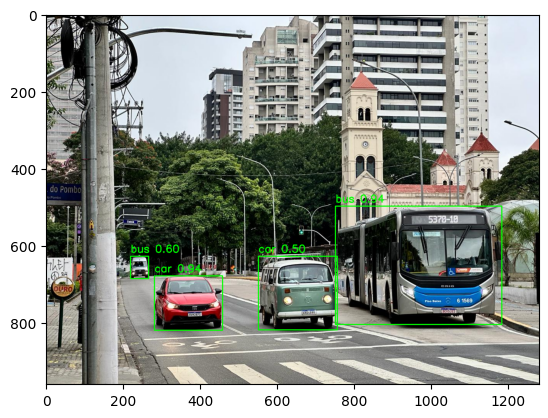

In [ ]:
# ---------- USER ACTIONS ----------
# 1. Upload and run image detection
uploaded_img = files.upload()
image_path = list(uploaded_img.keys())[0]
detect_vehicles_in_image(image_path)


In [ ]:
# 2. Upload and run video detection
uploaded_vid = files.upload()
video_path = list(uploaded_vid.keys())[0]
detect_vehicles_in_video(video_path)


Saving IMAGE.png to IMAGE (1).png

--- Running YOLOv8n on video ---


100%|██████████| 6.25M/6.25M [00:00<00:00, 251MB/s]



0: 448x640 11 cars, 2 trucks, 195.7ms
Speed: 5.4ms preprocess, 195.7ms inference, 16.3ms postprocess per image at shape (1, 3, 448, 640)
Video processing complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>